<h1> Activation Functions for Non-Linear Function Approximation</h1> <br>

<img src="https://upload.wikimedia.org/wikipedia/commons/4/42/ReLU_and_GELU.svg" width="500" align="center">


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt 
import random

In [20]:
def create_data(data_points):
    data_class1 = torch.rand(data_points, 2) * 1.45
    data_class2 = torch.rand(data_points, 2) * 3
    
    mask = ~((data_class2[:, 0] < 1.55) * (data_class2[:, 1] < 1.55))
    data_class2 = data_class2[mask]

    # Lables
    data_label1 = torch.zeros(data_class1.shape[0], 1)
    data_label2 = torch.ones(data_class2.shape[0], 1)

    # Combine data
    x_data = torch.cat((data_class1, data_class2), 0)
    y_data = torch.cat((data_label1, data_label2), 0)
    
    return x_data, y_data

x_train  , y_train = create_data(1000) 
x_test , y_test = create_data(500) 


### Plot the data 

In [21]:
y_train.flatten().numpy()

array([0., 0., 0., ..., 1., 1., 1.], dtype=float32)

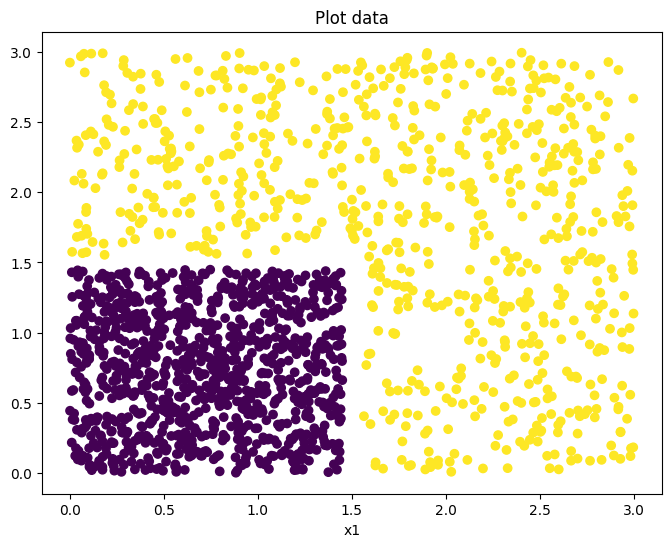

In [22]:
plt.figure(figsize=(8 , 6)) 
plt.scatter(x_train[: , 0] , x_train[: , 1] , c=y_train.flatten().numpy()) 
_ = plt.xlabel("x0") 
_ = plt.xlabel("x1") 
_ = plt.title("Plot data")

In [27]:
## creating the Linear Logistic Regression model 
logistic    = nn.Linear(2,1) 
loss = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(logistic.parameters(), lr=0.01) 


max_epoch = 100 
logistic_loss = [] 
logistic_acc = [] 

for epoch in range(max_epoch): 
    with torch.no_grad(): 
        y_test_hat = logistic(x_test) 
        # The descision boundary is at 0.5 (between 0 and 1) AFTER the sigmoid
        # The input to the Sigmoid function that gives 0.5 is 0!
        # Therefore the descision boundary for the RAW output is at 0!! 
        class_pred = (y_test_hat>0).float() 
        logistic_acc.append(float(sum(class_pred==y_test)) / float(y_test.shape[0])) 

    y_train_hat = logistic(x_train) 
    los = loss(y_train , y_train_hat) 

    optimizer.zero_grad() 
    los.backward() 
    optimizer.step() 
    logistic_loss.append(los.item()) 

print("Accuracy of Model ", (sum(logistic_acc) / len(logistic_acc))*100)

Accuracy of Model  41.656942823803966


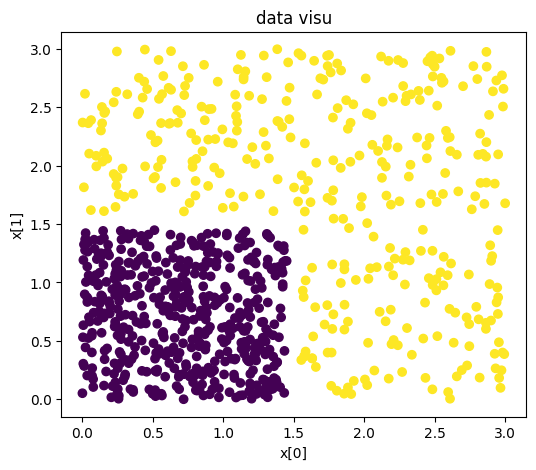

In [28]:
plt.figure(figsize=(6 , 5)) 
plt.scatter(x_test[: , 0].numpy() ,x_test[: ,1].numpy()  , c = y_test.flatten().numpy() ) 
_ = plt.title("data visu") 
_ = plt.xlabel("x[0]")
_ = plt.ylabel("x[1]")

<h2> Non-Linear function approximators! </h2> <br>

Up until now we have only created a single linear layer with an input layer and an output layer. In this section we will start to create multi-layered networks with many "hidden" layers separated by "activation functions" that give our networks "non-linearities". If we didn't have these activation functions and simply stacked layers together, our network would be no better than a single linear layer! Why? Because multiple sequential "linear transformations" can be modeled with just a single linear transformation. This is easiest to understand with matrix multiplications (which is exactly what happens inside a linear layer).<br>

$M_o = M_i*M_1*M_2*M_3*M_4*M_5$<br>
Is the same as<br>
$M_o = M_i*M_T$<br>
Where<br>
$M_T = M_1*M_2*M_3*M_4*M_5$<br>

Aka multiplication with several matrices can be simplified to multiplication with a single matrix.<br>

So what are these nonlinear activation functions that turn our simple linear models into a power "nonlinear function approximator"? Some common examples are:<br>
1. relu
2. sigmoid
3. tanh

Simply put they are "nonlinear" functions, the simplest of which is the "rectified linear unit" (relu) which is "piecewise non-linear".

NOTE: The term "layer" most commonly refers to the inputs or outputs of the weight matrix or activations functions and not the linear layer or activation layer themselves. Output layers in between two "linear layers" are called "hidden layers". You can imagine them "inside" the neural network with us only being able to see the input and output layers. To confuse things even further the outputs of activation functions are also commonly called "activations"

Why do we want a linear function approximator? Because many processes, tasks, systems in the real world are non-linear. "Linear" in basic terms refers to any process that takes inputs, scales them and sums them together to get an output. 

<h2>Train a Non-Linear Logistic Regression Model With Pytorch</h2>
Now that we have seen the power of a non-linear Neural Network let's see how we can create and train one automatically with Pytorch!

In [39]:
class NonLinearNN(nn.Module): 
    def __init__(self , input_size , output_size , hidden_size): 
        super(NonLinearNN , self).__init__()
        self.linear1 = nn.Linear(input_size , hidden_size) 
        self.linear2  = nn.Linear(hidden_size , output_size) 
        self.sigmoid = nn.Sigmoid()
    def forward(self , x): 
        self.h1 = self.linear1(x) 
        self.h2 =self.sigmoid(self.h1)
        self.h3 = self.linear2(self.h2) 

        return self.h3


model = NonLinearNN(input_size=2, output_size=1 , hidden_size=8 )
loss_func = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters() , lr=0.01) 



## training loop 

EPOCHS=50 

train_accu = [] 
test_accu = [] 
total_loss = [] 
test_loss = []
for epoch in range(EPOCHS):
    
    with torch.no_grad(): 
        y_pred = model(x_test) 
        class_pred = (y_pred>0).float() 
        test_accu.append(float(sum(class_pred==y_test))/float(y_test.shape[0]))
    
    y_pred = model(x_train)
    loss = loss_func(y_train , y_pred) 

    # class_pred = (y_pred>0).float() 
    train_accu.append(float(sum(y_pred==y_train))/float(y_train.shape[0]))
    optimizer.zero_grad()
    loss.backward() 
    optimizer.step() 

    total_loss.append(loss.item()) 

print("accuracy is " , test_accu[-1]*100)

accuracy is  41.656942823803966


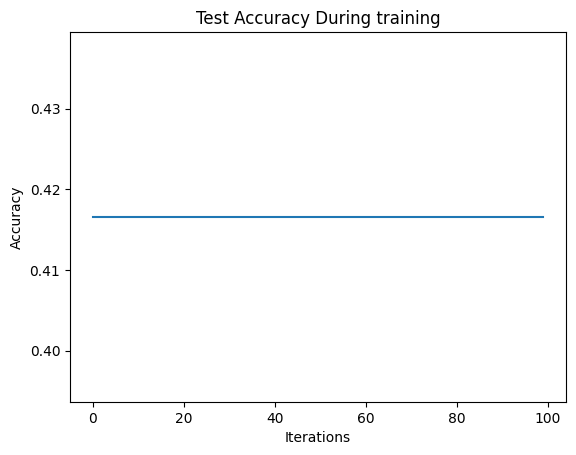

In [40]:
plt.plot(logistic_acc)
_ = plt.xlabel("Iterations")
_ = plt.ylabel("Accuracy")
_ = plt.title("Test Accuracy During training")